In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df_train = pd.read_csv(r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\data\raw\Image_train.csv" , header = None)

df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 2064 entries, 0 to 2063
Data columns (total 28 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       2064 non-null   str    
 1   1       2064 non-null   float64
 2   2       2064 non-null   int64  
 3   3       2064 non-null   float64
 4   4       2064 non-null   float64
 5   5       2064 non-null   float64
 6   6       2064 non-null   float64
 7   7       2064 non-null   float64
 8   8       2064 non-null   float64
 9   9       2064 non-null   float64
 10  10      2064 non-null   float64
 11  11      2064 non-null   float64
 12  12      2064 non-null   float64
 13  13      2064 non-null   float64
 14  14      2064 non-null   float64
 15  15      2064 non-null   float64
 16  16      2064 non-null   float64
 17  17      2064 non-null   float64
 18  18      2064 non-null   float64
 19  19      2064 non-null   float64
 20  20      2064 non-null   float64
 21  21      2064 non-null   float64
 22  22      206

In [3]:
df_train.isnull().sum()

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
20    0
21    0
22    0
23    0
24    0
25    0
26    0
27    0
dtype: int64

In [4]:
df_train.head(2)

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,001197_M_18_180340_5443109.jpg,16.736433,1,0.76096,0.485597,0.800905,1.612940,2.013897,4.980746,4.105896,...,19.905191,0.0,0.0,20.950941,20.478027,0.0,0.0,18,1.8034,54.43109
1,0_M_33_187960_19277677.jpg,54.566215,1,1.23708,2.747253,1.146789,2.819359,2.458481,1.529249,2.262845,...,39.689133,0.0,0.0,40.617210,39.593468,0.0,0.0,33,1.8796,192.77677


In [5]:
df_train.iloc[0, [0, 1, 2, 25, 26, 27]]


0     001197_M_18_180340_5443109.jpg
1                          16.736433
2                                  1
25                                18
26                            1.8034
27                          54.43109
Name: 0, dtype: object

In [6]:
#Test Data

In [7]:
df_test_raw = pd.read_csv(r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\data\raw\Image_test.csv", header=None)

In [8]:
## Extrating the Image name, bmi Gender, age , height, weight

In [9]:
df_clean = df_train[[0, 1, 2, 25, 26, 27]].copy()

In [10]:
df_clean.columns = ['image_name', 'bmi', 'gender', 'age', 'height', 'weight']

In [11]:
df_clean.head()

,image_name,bmi,gender,age,height,weight
0,001197_M_18_180340_5443109.jpg,16.736433,1,18,1.8034,54.43109
1,0_M_33_187960_19277677.jpg,54.566215,1,33,1.8796,192.77677
2,000558_M_33_172720_11403313.jpg,38.224850,1,33,1.7272,114.03313
3,000614_M_40_175260_9071848.jpg,29.534536,1,40,1.7526,90.71848
4,000728_F_28_167640_8391459.jpg,29.859475,0,28,1.6764,83.91459


In [12]:
#converting height from meter to cm 

In [13]:
df_clean['height_cm'] = df_clean['height'] * 100

In [14]:
df_clean = df_clean.drop(columns=['height'])

In [15]:
df_clean.isnull().sum()

image_name    0
bmi           0
gender        0
age           0
weight        0
height_cm     0
dtype: int64

In [16]:
df_clean.describe()

,bmi,gender,age,weight,height_cm
count,2064.000000,2064.000000,2064.000000,2064.000000,2064.000000
mean,30.581077,0.500000,26.757752,91.630253,172.706586
std,9.077824,0.500121,6.064801,30.266501,10.696066
min,10.493576,0.000000,15.000000,29.483510,127.000000
25%,24.393785,0.000000,22.000000,71.667590,165.100000
50%,28.321894,0.500000,26.000000,83.914590,172.720000
75%,34.456521,1.000000,30.000000,104.326250,180.340000
max,78.614719,1.000000,56.000000,254.011740,200.660000


In [17]:
# Same Operations on Test data

In [18]:
df_test = df_test_raw[[0, 1, 2, 25, 26, 27]].copy()

df_test.columns = ['image_name', 'bmi', 'gender', 'age', 'height_m', 'weight'] 

df_test['height_cm'] = df_test['height_m'] * 100
df_test = df_test.drop(columns=['height_m'])

In [19]:
# Data Exploration

In [20]:
for col in ['bmi', 'height_cm', 'weight']:
    mean_val = df_clean[col].mean()
    print(f"Target {col}: Naive prediction is {mean_val:.2f}")

Target bmi: Naive prediction is 30.58
Target height_cm: Naive prediction is 172.71
Target weight: Naive prediction is 91.63


In [21]:
df_clean['gender'].value_counts()

gender
1    1032
0    1032
Name: count, dtype: int64

In [22]:
## Visualisation

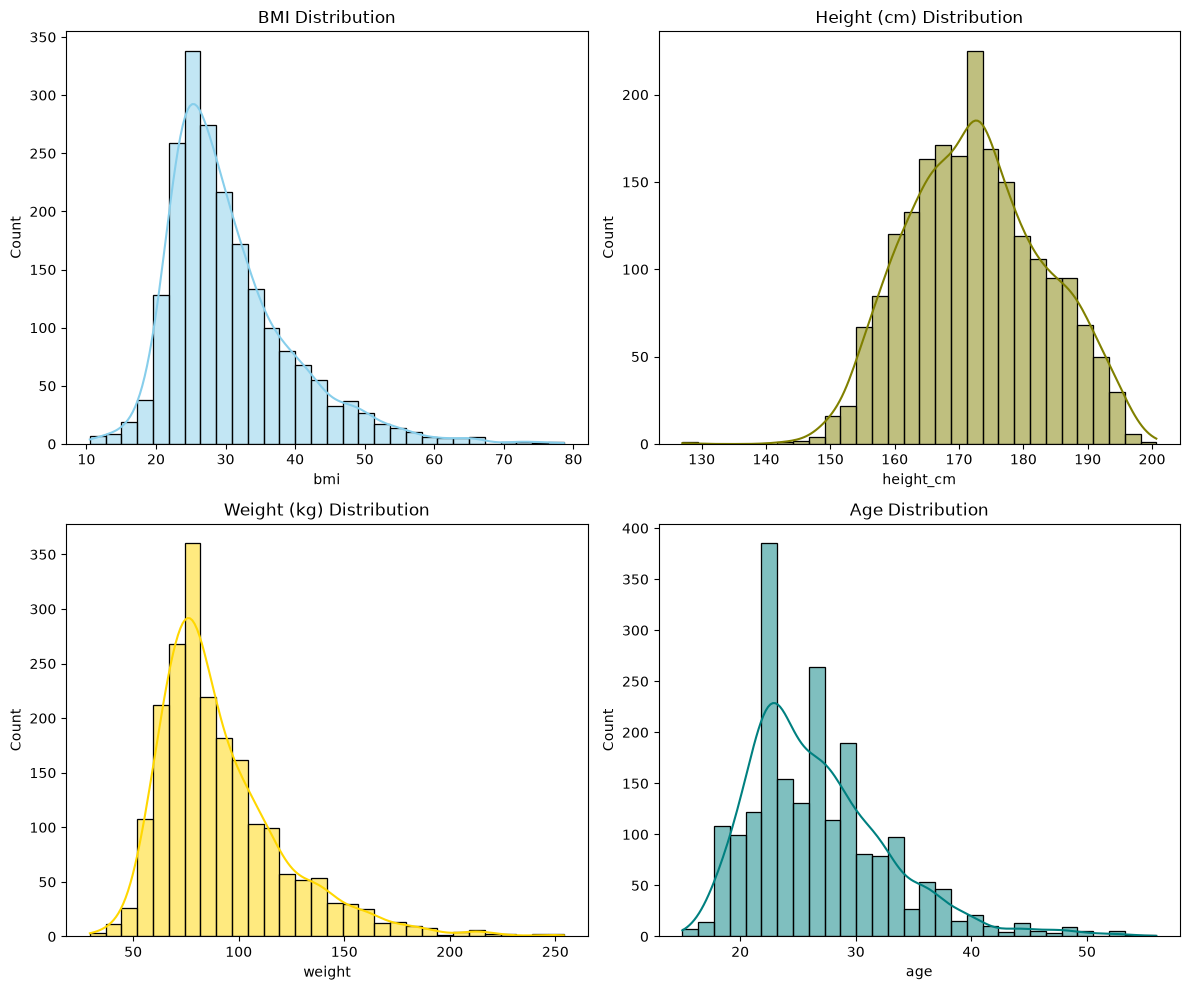

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10)) 

sns.histplot(df_clean['bmi'], bins=30, ax=axes[0, 0], kde=True, color='skyblue')
axes[0, 0].set_title('BMI Distribution')

sns.histplot(df_clean['height_cm'], bins=30, ax=axes[0, 1], kde=True, color='olive')
axes[0, 1].set_title('Height (cm) Distribution') 

sns.histplot(df_clean['weight'], bins=30, ax=axes[1, 0], kde=True, color='gold')
axes[1, 0].set_title('Weight (kg) Distribution') 

sns.histplot(df_clean['age'], bins=30, ax=axes[1, 1], kde=True, color='teal')
axes[1, 1].set_title('Age Distribution') 

plt.tight_layout()
plt.show()

In [24]:
# Applying Domain Bounded Hard Filters

In [25]:
len(df_clean)

2064

### Handling Outliers

In [26]:
df_filtered = df_clean.copy()

In [27]:
#age should be greater or equal to 18 and should be lower than 90

In [28]:
df_filtered = df_filtered[(df_filtered['age'] >= 18) & (df_filtered['age'] <= 90)].copy()

In [29]:
# height between 120cm to 220cm 

In [30]:
df_filtered = df_filtered[(df_filtered['height_cm'] >= 120) & (df_filtered['height_cm'] <= 220)]

In [31]:
# weight between 30 to 200 kgs

In [32]:
df_filtered = df_filtered[(df_filtered['weight'] >= 30) & (df_filtered['weight'] <= 200)]

In [33]:
# bmi range between 12 to 60

In [34]:
df_filtered = df_filtered[(df_filtered['bmi'] >= 12) & (df_filtered['bmi'] <= 60)].copy()

In [35]:
len(df_filtered)

2012

In [36]:
df_filtered.to_csv(r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\data\processed\train_clean_v1.csv", index=False)

In [37]:
# Test Data

In [38]:
df_test = df_test[(df_test['age'] >= 18) & (df_test['age'] <= 90)]
df_test = df_test[(df_test['height_cm'] >= 120) & (df_test['height_cm'] <= 220)]
df_test = df_test[(df_test['weight'] >= 30) & (df_test['weight'] <= 200)]
df_test = df_test[(df_test['bmi'] >= 12) & (df_test['bmi'] <= 60)] 

## FEATURE ENGINEERING

### Target Scaling 

In [39]:
import os
import joblib
from sklearn.preprocessing import StandardScaler 

df_train = pd.read_csv(r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\data\processed\train_split.csv")
df_test = pd.read_csv(r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\data\processed\test_engineered_v1.csv")

In [40]:
df_test.shape , df_train.shape

((873, 8), (2012, 8))

In [41]:
# Storing the Scaler 

In [42]:
os.makedirs(r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\models\preprocessing", exist_ok=True)

In [43]:
## Target Scaling.

In [44]:
targets_to_scale = ['height_cm', 'weight']

for col in targets_to_scale:
    scaler = StandardScaler()
    
    df_train[f'{col}_scaled'] = scaler.fit_transform(df_train[[col]])
    df_test[f'{col}_scaled'] = scaler.transform(df_test[[col]])
    
    scaler_path = rf"C:\Users\mishr\PROJECTS\P4-PulseFit\models\preprocessing\{col}_scaler.pkl"
    joblib.dump(scaler, scaler_path)

In [45]:
df_train.to_csv(r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\data\processed\train_final.csv", index=False)
df_test.to_csv(r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\data\processed\test_final.csv", index=False)

In [46]:
df_train.head()

,image_name,bmi,gender,age,weight,height_cm,bmi_category,bmi_category_encoded,height_cm_scaled,weight_scaled
0,001197_M_18_180340_5443109.jpg,16.736433,1,18,54.43109,180.34,Underweight,3,0.721418,-1.325634
1,0_M_33_187960_19277677.jpg,54.566215,1,33,192.77677,187.96,Obese,1,1.434928,3.770727
2,000558_M_33_172720_11403313.jpg,38.224850,1,33,114.03313,172.72,Obese,1,0.007908,0.869978
3,000614_M_40_175260_9071848.jpg,29.534536,1,40,90.71848,175.26,Overweight,2,0.245745,0.011116
4,000728_F_28_167640_8391459.jpg,29.859475,0,28,83.91459,167.64,Overweight,2,-0.467765,-0.239525


## DataLoader & Data Pipeline 

In [47]:
# Multi output batching

In [48]:
import torch
from torch.utils.data import Dataset
from PIL import Image


class BiometricDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform
        
        self.image_names = df['image_name'].values
        self.height = df['height_cm_scaled'].values
        self.weight = df['weight_scaled'].values

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        raw_name = str(self.image_names[idx]).strip()
        raw_name = raw_name.replace(']', '').replace('[', '')
        
        img_path = os.path.join(self.img_dir, raw_name)
        
        if not os.path.exists(img_path):
            base_name = os.path.splitext(raw_name)[0]
            found = False
            for ext in ['.jpg', '.jpeg', '.png']:
                test_path = os.path.join(self.img_dir, base_name + ext)
                if os.path.exists(test_path):
                    img_path = test_path
                    found = True
                    break
            if not found:
                raise FileNotFoundError(f"Could not resolve image file for: {raw_name}")
        
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        targets = {
            "height_out": torch.tensor(self.height[idx], dtype=torch.float32),
            "weight_out": torch.tensor(self.weight[idx], dtype=torch.float32)
        }
        return image, targets

In [49]:
# purging ( deleting ) the files that dont exist in image_train

In [50]:
train_csv_path = r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\data\processed\train_final.csv"
train_img_dir = r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\data\raw\Image_train"

df_check = pd.read_csv(train_csv_path)

def image_exists(img_name):
    img_path = os.path.join(train_img_dir, str(img_name))
    if os.path.exists(img_path): 
        return True
    
    base = str(img_name).split('.')[0]
    for ext in ['.jpg', '.jpeg', '.png']:
        if os.path.exists(os.path.join(train_img_dir, base + ext)): 
            return True
    return False

df_check['exists'] = df_check['image_name'].apply(image_exists)
df_clean = df_check[df_check['exists'] == True].drop(columns=['exists'])

print(f"Purged {len(df_check) - len(df_clean)} missing ghost images.")

df_clean.to_csv(train_csv_path, index=False)

Purged 1 missing ghost images.


## Merging the Train and test Data Set (for cross validation ) since i have low data

In [51]:
train_path = r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\data\processed\train_clean_v1.csv"
test_path = r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\data\processed\test_engineered_v1.csv"

df_tr = pd.read_csv(train_path)
df_te = pd.read_csv(test_path)

df_master = pd.concat([df_tr, df_te], ignore_index=True)
print(f"Master Dataset Combined Shape: {df_master.shape}")

os.makedirs(r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\models\preprocessing", exist_ok=True)
targets_to_scale = ['height_cm', 'weight']

for col in targets_to_scale:
    scaler = StandardScaler()
    df_master[f'{col}_scaled'] = scaler.fit_transform(df_master[[col]])
    
    scaler_path = rf"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\models\preprocessing\{col}_scaler.pkl"
    joblib.dump(scaler, scaler_path)

master_csv_path = r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\data\processed\master_dataset.csv"
df_master.to_csv(master_csv_path, index=False)
print(f"Master dataset saved successfully at: {master_csv_path}")

Master Dataset Combined Shape: (2885, 8)
Master dataset saved successfully at: C:\Users\mishr\PROJECTS\P4-Pulse-Fit\data\processed\master_dataset.csv


In [52]:
# Data Augmentation and Transformation 

In [53]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10), 
    transforms.RandomAffine(
        degrees=0,          
        translate=(0.05, 0.05), 
        scale=(0.90, 1.10)      
    ),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [54]:
#Train Loader

In [55]:
from torch.utils.data import random_split, DataLoader

train_img_dir = r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\data\raw\Image_train"
master_csv_path = r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\data\processed\master_dataset.csv"

full_dataset = BiometricDataset(
    csv_file=master_csv_path, 
    img_dir=train_img_dir, 
    transform=train_transform
)

total_size = len(full_dataset)
val_size = 450
train_size = total_size - val_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

val_dataset.dataset.transform = val_transform

train_loader = DataLoader(
    train_dataset, 
    batch_size=32, 
    shuffle=True, 
    num_workers=0, 
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=32, 
    shuffle=False, 
    num_workers=0, 
    pin_memory=True
)

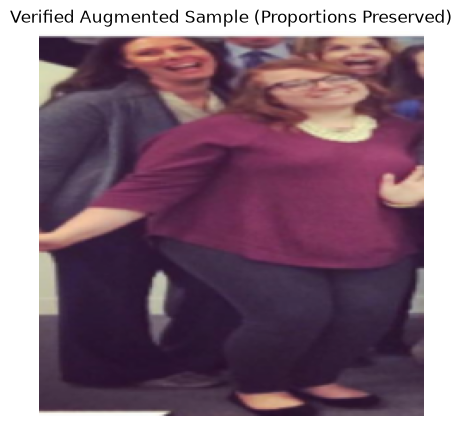

In [56]:
for images, targets in train_loader:
    break

# Denormalize and convert tensor to viewable numpy image
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

sample_img = images[0].permute(1, 2, 0).numpy()
sample_img = (sample_img * std) + mean
sample_img = np.clip(sample_img, 0, 1) 

plt.figure(figsize=(5, 5))
plt.imshow(sample_img)
plt.title("Verified Augmented Sample (Proportions Preserved)")
plt.axis('off')
plt.show()

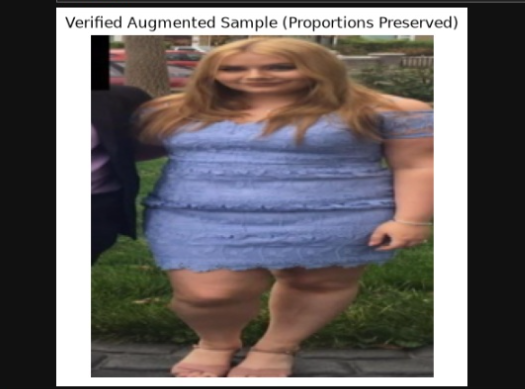
This Girl must not look like this its stretched pic and if we train our model on these then it will predict her to be fat but we can see her pic is stretched making her look fat

If i train a neural network on horizontally stretched images, the model would learn corrupted body geometries. It would look at a stretched, normal-weight person, see a wider waistline caused by bad math, and falsely predict a higher BMI

### SQUARE PADDING ( to fix this problem )

In [57]:
import joblib
from sklearn.preprocessing import StandardScaler
import torchvision.transforms.functional as TF
from torchvision import transforms

class SquarePad:
    def __call__(self, img):
        w, h = img.size
        max_wh = max(w, h)
        hp = (max_wh - w) // 2
        vp = (max_wh - h) // 2
        padding = (hp, vp, max_wh - w - hp, max_wh - h - vp)
        return TF.pad(img, padding, fill=0, padding_mode='constant')

train_transform_padded = transforms.Compose([
    SquarePad(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(
        degrees=0, 
        translate=(0.05, 0.05),
        scale=(0.90, 1.10)
    ),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform_padded = transforms.Compose([
    SquarePad(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [58]:
train_img_dir = r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\data\raw\Image_train"
master_csv_path = r"C:\Users\mishr\PROJECTS\P4-Pulse-Fit\data\processed\master_dataset.csv"

padded_dataset = BiometricDataset(
    csv_file=master_csv_path, 
    img_dir=train_img_dir, 
    transform=train_transform_padded
) 

total_size = len(padded_dataset)
val_size = 450
train_size = total_size - val_size

train_dataset, val_dataset = random_split(padded_dataset, [train_size, val_size])

val_dataset.dataset.transform = val_transform_padded

In [59]:
## Train Validation Split and DataLoader

In [60]:
train_loader = DataLoader(
    train_dataset, 
    batch_size=32, 
    shuffle=True, 
    num_workers=0, 
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=32, 
    shuffle=False, 
    num_workers=0, 
    pin_memory=True
)

In [61]:
import time 

print("Running DataLoader Benchmark")
start_time = time.time()
batch_count = 10

for i, (images, targets) in enumerate(train_loader):
    if i >= batch_count:
        break

elapsed = time.time() - start_time
batches_per_sec = batch_count / elapsed

print(f"Pipeline Speed: {batches_per_sec:.2f} Batches/Second")
print(f"Batch Tensor Shape: {images.shape}")
print(f"Target Keys Verified: {list(targets.keys())}")

Running DataLoader Benchmark
Pipeline Speed: 1.06 Batches/Second
Batch Tensor Shape: torch.Size([32, 3, 224, 224])
Target Keys Verified: ['height_out', 'weight_out']


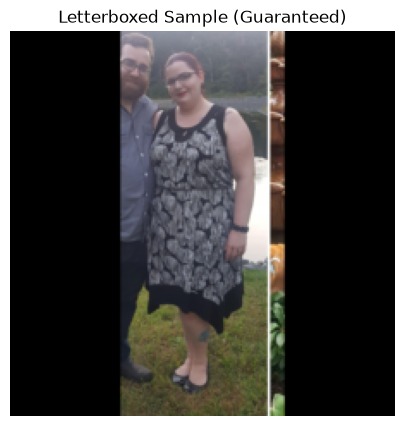

In [62]:
for images, targets in train_loader:
    break 

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

sample_img = images[0].permute(1, 2, 0).numpy()
sample_img = (sample_img * std) + mean
sample_img = np.clip(sample_img, 0, 1) 

plt.figure(figsize=(5, 5))
plt.imshow(sample_img)
plt.title("Letterboxed Sample (Guaranteed)")
plt.axis('off')
plt.show()

### CNN and Transfer Learning ( EfficientNetB0 )

In [63]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {device}")

Using Device: cuda


In [64]:
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights 

class PulseFitNetwork(nn.Module):
    def __init__(self):
        super(PulseFitNetwork, self).__init__()
        
        weights = EfficientNet_B0_Weights.DEFAULT
        self.backbone = efficientnet_b0(weights=weights)
        
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()
        
        self.shared_fc = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.6) 
        )

        self.height_head = nn.Sequential(
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )
        
        self.weight_head = nn.Sequential(
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        shared_features = self.backbone(x)
        shared_features = self.shared_fc(shared_features)
        
        return {
            "height_out": self.height_head(shared_features).squeeze(1),
            "weight_out": self.weight_head(shared_features).squeeze(1)
        }

In [65]:
model = PulseFitNetwork().to(device)

In [66]:
import torch.optim as optim

criterion_regression = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

In [67]:
## Freezing layers of EfficientNetB0

In [68]:
def freeze_backbone(model):
    for param in model.backbone.parameters():
        param.requires_grad = False
    
    for param in model.shared_fc.parameters():
        param.requires_grad = True
    for param in model.height_head.parameters():
        param.requires_grad = True
    for param in model.weight_head.parameters():
        param.requires_grad = True
        
    return model

model = freeze_backbone(model)

In [69]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = sum(p.numel() for p in model.parameters() if not p.requires_grad)

print(f"Frozen Parameters: {frozen_params}")
print(f"Trainable Parameters: {trainable_params}")

Frozen Parameters: 4007548
Trainable Parameters: 361474


In [70]:
# Loss function and Optimizer

In [71]:
import torch.optim as optim

criterion_regression = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

loss_weights = {"height": 1.0, "weight": 2.0} 

trainable_params = filter(lambda p: p.requires_grad, model.parameters())

### Multi task Training Loop ( warmup )

In [72]:
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    start_time = time.time()
    
    for batch_idx, (images, targets) in enumerate(train_loader):
        images = images.to(device)
        targets = {k: v.to(device) for k, v in targets.items()}
        
        optimizer.zero_grad()
        outputs = model(images)
        
        loss_height = criterion_regression(outputs["height_out"], targets["height_out"].float())
        loss_weight = criterion_regression(outputs["weight_out"], targets["weight_out"].float())
        
        total_loss = (loss_weights["height"] * loss_height) + (loss_weights["weight"] * loss_weight)
        
        total_loss.backward()
        optimizer.step()
        running_loss += total_loss.item()
        
        
        if (batch_idx + 1) % 10 == 0 or (batch_idx + 1) == len(train_loader):
            print(f"Epoch [{epoch+1}/{epochs}] , Batch [{batch_idx+1}/{len(train_loader)}] , Total Batch Loss: {total_loss.item():.4f}")
            
    epoch_loss = running_loss / len(train_loader)
    elapsed = time.time() - start_time
    print(f"Epoch {epoch+1} Completed in {elapsed:.1f}s | Average Loss: {epoch_loss:.4f}\n")

Epoch [1/5] , Batch [10/77] , Total Batch Loss: 2.8532
Epoch [1/5] , Batch [20/77] , Total Batch Loss: 4.7716
Epoch [1/5] , Batch [30/77] , Total Batch Loss: 3.9775
Epoch [1/5] , Batch [40/77] , Total Batch Loss: 3.9476
Epoch [1/5] , Batch [50/77] , Total Batch Loss: 2.9871
Epoch [1/5] , Batch [60/77] , Total Batch Loss: 2.9859
Epoch [1/5] , Batch [70/77] , Total Batch Loss: 2.5524
Epoch [1/5] , Batch [77/77] , Total Batch Loss: 1.0579
Epoch 1 Completed in 70.2s | Average Loss: 3.1524

Epoch [2/5] , Batch [10/77] , Total Batch Loss: 4.0083
Epoch [2/5] , Batch [20/77] , Total Batch Loss: 2.7242
Epoch [2/5] , Batch [30/77] , Total Batch Loss: 2.9079
Epoch [2/5] , Batch [40/77] , Total Batch Loss: 2.4192
Epoch [2/5] , Batch [50/77] , Total Batch Loss: 2.3438
Epoch [2/5] , Batch [60/77] , Total Batch Loss: 2.1828
Epoch [2/5] , Batch [70/77] , Total Batch Loss: 2.5744
Epoch [2/5] , Batch [77/77] , Total Batch Loss: 1.9073
Epoch 2 Completed in 68.6s | Average Loss: 2.9275

Epoch [3/5] , Batc

### Validation of this Warmup CNN model 

In [73]:
model.eval()
val_metrics = {"loss": 0.0, "height_mae": 0.0, "weight_mae": 0.0, "total_samples": 0}

In [74]:
with torch.no_grad():
    for images, targets in val_loader:
        images = images.to(device)
        targets = {k: v.to(device) for k, v in targets.items()}
        
        outputs = model(images)
        
        loss_height = criterion_regression(outputs["height_out"], targets["height_out"].float())
        loss_weight = criterion_regression(outputs["weight_out"], targets["weight_out"].float())
        
        batch_loss = (loss_weights["height"] * loss_height) + (loss_weights["weight"] * loss_weight)
        
        val_metrics["loss"] += batch_loss.item()
        val_metrics["total_samples"] += images.size(0)
        
        val_metrics["height_mae"] += torch.abs(outputs["height_out"] - targets["height_out"]).sum().item()
        val_metrics["weight_mae"] += torch.abs(outputs["weight_out"] - targets["weight_out"]).sum().item()

num_batches = len(val_loader)
total_samples = val_metrics["total_samples"]
elapsed = time.time() - start_time

print(f"Validation Completed in {elapsed:.1f}s")
print(f"Total Val Loss: {val_metrics['loss'] / num_batches:.4f}")
print(f"Scaled Height MAE: ±{val_metrics['height_mae'] / total_samples:.4f}")
print(f"Scaled Weight MAE: ±{val_metrics['weight_mae'] / total_samples:.4f}")

Validation Completed in 82.1s
Total Val Loss: 2.1707
Scaled Height MAE: ±0.7363
Scaled Weight MAE: ±0.6700


The Error in the Height weight is the error in scaled scores means after Inversing the value the actual error is high 

## Fine-Tuning and Unfreezing the layers of EfficientNetB0

In [75]:
def extreme_unfreeze(model):
    for param in model.parameters():
        param.requires_grad = False
        
    for param in model.backbone.features[8].parameters():
        param.requires_grad = True
        
    for param in model.shared_fc.parameters():
        param.requires_grad = True
    for param in model.height_head.parameters():
        param.requires_grad = True
    for param in model.weight_head.parameters():
        param.requires_grad = True
        
    return model

model = extreme_unfreeze(model)

optimizer_finetune = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-3)

In [76]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = sum(p.numel() for p in model.parameters() if not p.requires_grad) 

print(f"Frozen Parameters (Low-level features): {frozen_params}")
print(f"Trainable Parameters (Deep features + Heads): {trainable_params}")

Frozen Parameters (Low-level features): 3595388
Trainable Parameters (Deep features + Heads): 773634


In [77]:
epochs = 10
best_val_loss = float('inf')
model_save_path = "pulse_fit_best_model.pth"

In [78]:
epochs_ft = 100
best_val_loss = float('inf')
model_save_path = "pulse_fit_best_model.pth"

patience = 5
patience_counter = 0

print(f"\n Deep FineTuning")

for epoch in range(epochs_ft):
    epoch_start_time = time.time()
    
#training
    model.train()
    running_train_loss = 0.0
    
    for batch_idx, (images, targets) in enumerate(train_loader):
        images = images.to(device)
        targets = {k: v.to(device) for k, v in targets.items()}
        
        optimizer_finetune.zero_grad()
        
        outputs = model(images)
        
        loss_height = criterion_regression(outputs["height_out"], targets["height_out"].float())
        loss_weight = criterion_regression(outputs["weight_out"], targets["weight_out"].float())
        
        total_train_loss = (loss_weights["height"] * loss_height) + (loss_weights["weight"] * loss_weight)
        
        total_train_loss.backward()
        optimizer_finetune.step()
        
        running_train_loss += total_train_loss.item()
        
    avg_train_loss = running_train_loss / len(train_loader)

#validation
    model.eval()
    running_val_loss = 0.0
    val_metrics = {"height_mae": 0.0, "weight_mae": 0.0, "total_samples": 0}
    
    with torch.no_grad():
        for images, targets in val_loader:
            images = images.to(device)
            targets = {k: v.to(device) for k, v in targets.items()}
            
            outputs = model(images)
            
            loss_height = criterion_regression(outputs["height_out"], targets["height_out"].float())
            loss_weight = criterion_regression(outputs["weight_out"], targets["weight_out"].float())
            
            batch_val_loss = (loss_weights["height"] * loss_height) + (loss_weights["weight"] * loss_weight)
            running_val_loss += batch_val_loss.item()
            
            val_metrics["total_samples"] += images.size(0)
            
            val_metrics["height_mae"] += torch.abs(outputs["height_out"] - targets["height_out"]).sum().item()
            val_metrics["weight_mae"] += torch.abs(outputs["weight_out"] - targets["weight_out"]).sum().item()

    avg_val_loss = running_val_loss / len(val_loader)
    total_samples = val_metrics["total_samples"]
    elapsed = time.time() - epoch_start_time
    
#early stopping
    is_best = avg_val_loss < best_val_loss
    if is_best:
        best_val_loss = avg_val_loss
        patience_counter = 0 # Reset patience
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer_finetune.state_dict(),
            'val_loss': best_val_loss
        }, model_save_path)
        checkpoint_msg = "NEW BEST MODEL SAVED!"
    else:
        patience_counter += 1
        checkpoint_msg = f"No improvement ({patience_counter}/{patience})"

    print(f"Epoch [{epoch+1}/{epochs_ft}] ({elapsed:.1f}s) | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    print(f"--Scaled Height MAE: ±{val_metrics['height_mae'] / total_samples:.4f} | Scaled Weight MAE: ±{val_metrics['weight_mae'] / total_samples:.4f} {checkpoint_msg}")

    # Trigger Early Stopping
    if patience_counter >= patience:
        print(f"\nEarly Stopping Triggered! Validation loss hasn't improved for {patience} epochs.")
        break

print(f"\nBest Validation Loss achieved: {best_val_loss:.4f}")


 Deep FineTuning
Epoch [1/100] (81.6s) | Train Loss: 2.4571 | Val Loss: 2.1942
--Scaled Height MAE: ±0.7334 | Scaled Weight MAE: ±0.6670 NEW BEST MODEL SAVED!
Epoch [2/100] (83.2s) | Train Loss: 2.4746 | Val Loss: 2.1743
--Scaled Height MAE: ±0.7264 | Scaled Weight MAE: ±0.6616 NEW BEST MODEL SAVED!
Epoch [3/100] (84.5s) | Train Loss: 2.5579 | Val Loss: 2.1889
--Scaled Height MAE: ±0.7282 | Scaled Weight MAE: ±0.6587 No improvement (1/5)
Epoch [4/100] (83.8s) | Train Loss: 2.4948 | Val Loss: 2.1744
--Scaled Height MAE: ±0.7226 | Scaled Weight MAE: ±0.6565 No improvement (2/5)
Epoch [5/100] (80.9s) | Train Loss: 2.4136 | Val Loss: 2.1704
--Scaled Height MAE: ±0.7265 | Scaled Weight MAE: ±0.6703 NEW BEST MODEL SAVED!
Epoch [6/100] (74.3s) | Train Loss: 2.5467 | Val Loss: 2.1699
--Scaled Height MAE: ±0.7251 | Scaled Weight MAE: ±0.6614 NEW BEST MODEL SAVED!
Epoch [7/100] (70.9s) | Train Loss: 2.4269 | Val Loss: 2.1586
--Scaled Height MAE: ±0.7243 | Scaled Weight MAE: ±0.6611 NEW BEST MOD

In [79]:
import torch
import joblib
import numpy as np

# 1. Load your saved Scalers
height_scaler = joblib.load(r"C:\Users\mishr\PROJECTS\P4-PulseFit\models\preprocessing\height_cm_scaler.pkl")
weight_scaler = joblib.load(r"C:\Users\mishr\PROJECTS\P4-PulseFit\models\preprocessing\weight_scaler.pkl")

# 2. Load the BEST model weights we just saved from Early Stopping
model.load_state_dict(torch.load("pulse_fit_best_model.pth")['model_state_dict'])
model.eval()

real_height_mae = 0.0
real_weight_mae = 0.0
total_samples = 0

print("🔍 Calculating Real-World Error Metrics...")

with torch.no_grad():
    for images, targets in val_loader:
        images = images.to(device)
        outputs = model(images)
        
        # Move predictions to CPU and convert to numpy arrays
        pred_h_scaled = outputs["height_out"].cpu().numpy().reshape(-1, 1)
        true_h_scaled = targets["height_out"].cpu().numpy().reshape(-1, 1)
        
        pred_w_scaled = outputs["weight_out"].cpu().numpy().reshape(-1, 1)
        true_w_scaled = targets["weight_out"].cpu().numpy().reshape(-1, 1)
        
        # INVERSE TRANSFORM: Convert back to CM and KG
        pred_h_real = height_scaler.inverse_transform(pred_h_scaled)
        true_h_real = height_scaler.inverse_transform(true_h_scaled)
        
        pred_w_real = weight_scaler.inverse_transform(pred_w_scaled)
        true_w_real = weight_scaler.inverse_transform(true_w_scaled)
        
        # Calculate Absolute Errors in real units
        real_height_mae += np.sum(np.abs(pred_h_real - true_h_real))
        real_weight_mae += np.sum(np.abs(pred_w_real - true_w_real))
        
        total_samples += images.size(0)

final_h_mae = real_height_mae / total_samples
final_w_mae = real_weight_mae / total_samples

print("\n📊 FINAL REAL-WORLD MODEL PERFORMANCE 📊")
print(f"📏 Average Height Error: ±{final_h_mae:.2f} cm")
print(f"⚖️ Average Weight Error: ±{final_w_mae:.2f} kg")

🔍 Calculating Real-World Error Metrics...

📊 FINAL REAL-WORLD MODEL PERFORMANCE 📊
📏 Average Height Error: ±7.68 cm
⚖️ Average Weight Error: ±18.13 kg


## Model Optimization ( Using OPTUNA and Learning Rate Schelduler )

In [83]:
## Optuna Hyperparameter Tuning

In [87]:
from torch.optim.lr_scheduler import ReduceLROnPlateau 
import optuna


def objective(trial):
    lr = trial.suggest_float("lr", 1e-6, 1e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-4, 1e-1, log=True)
    dropout_rate = trial.suggest_float("dropout_rate", 0.4, 0.7)
    weight_penalty = trial.suggest_float("weight_penalty", 1.0, 3.0) 

    class OptunaPulseFitNetwork(nn.Module):
        def __init__(self):
            super(OptunaPulseFitNetwork, self).__init__()
            weights = EfficientNet_B0_Weights.DEFAULT
            self.backbone = efficientnet_b0(weights=weights)
            in_features = self.backbone.classifier[1].in_features
            self.backbone.classifier = nn.Identity()
            
            self.shared_fc = nn.Sequential(
                nn.Linear(in_features, 256),
                nn.BatchNorm1d(256),
                nn.ReLU(),
                nn.Dropout(dropout_rate) # Tuned Dropout!
            )
            self.height_head = nn.Sequential(nn.Linear(256, 64), nn.ReLU(), nn.Dropout(dropout_rate/2), nn.Linear(64, 1))
            self.weight_head = nn.Sequential(nn.Linear(256, 64), nn.ReLU(), nn.Dropout(dropout_rate/2), nn.Linear(64, 1))

        def forward(self, x):
            shared = self.shared_fc(self.backbone(x))
            return {"height_out": self.height_head(shared).squeeze(1), "weight_out": self.weight_head(shared).squeeze(1)}

    model = OptunaPulseFitNetwork().to(device) 

    #freezing
    for param in model.parameters(): param.requires_grad = False
    for param in model.backbone.features[8].parameters(): param.requires_grad = True
    for param in model.shared_fc.parameters(): param.requires_grad = True
    for param in model.height_head.parameters(): param.requires_grad = True
    for param in model.weight_head.parameters(): param.requires_grad = True

    # Optimizer & Scheduler
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    criterion_regression = nn.MSELoss()
    loss_weights = {"height": 1.0, "weight": weight_penalty} 


    # 4. 🏃‍♂️ Mini Training Loop (10 Epochs per Trial)
    for epoch in range(10):
        model.train()
        for images, targets in train_loader:
            images = images.to(device)
            targets = {k: v.to(device) for k, v in targets.items()}
            
            optimizer.zero_grad()
            outputs = model(images)
            loss_h = criterion_regression(outputs["height_out"], targets["height_out"].float())
            loss_w = criterion_regression(outputs["weight_out"], targets["weight_out"].float())
            loss = (loss_weights["height"] * loss_h) + (loss_weights["weight"] * loss_w)
            loss.backward()
            optimizer.step()
            
        # Validation for Scheduler & Optuna
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, targets in val_loader:
                images = images.to(device)
                targets = {k: v.to(device) for k, v in targets.items()}
                outputs = model(images)
                loss_h = criterion_regression(outputs["height_out"], targets["height_out"].float())
                loss_w = criterion_regression(outputs["weight_out"], targets["weight_out"].float())
                val_loss += ((loss_weights["height"] * loss_h) + (loss_weights["weight"] * loss_w)).item()
                
        val_loss /= len(val_loader)
        
        # Scheduler steps dynamically based on validation loss!
        scheduler.step(val_loss)
        
        # Report back to Optuna (allows it to kill bad runs early)
        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
            
    return val_loss

print("✅ Optuna Objective Function Ready!")

✅ Optuna Objective Function Ready!


C:\Users\mishr\anaconda3\envs\ml_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
print("🚀 Launching Optuna Hyperparameter Search...")
study = optuna.create_study(direction="minimize", pruner=optuna.pruners.MedianPruner())
study.optimize(objective, n_trials=15)

print("\n🏆 Best Trial Found:")
print(f"  Loss: {study.best_trial.value}")
print(f"  Params: {study.best_trial.params}")

[I 2026-08-26 13:52:01,912] A new study created in memory with name: no-name-65330cb2-1902-4a00-aab0-9c893c41d6df


🚀 Launching Optuna Hyperparameter Search...


[I 2026-08-26 14:02:59,457] Trial 0 finished with value: 3.293192658821742 and parameters: {'lr': 1.2468586024403439e-06, 'weight_decay': 0.03893651325054631, 'dropout_rate': 0.6105587889213948, 'weight_penalty': 2.826272630817465}. Best is trial 0 with value: 3.293192658821742.
[I 2026-08-26 14:13:48,929] Trial 1 finished with value: 2.738971296946208 and parameters: {'lr': 1.8788066426512843e-06, 'weight_decay': 0.013749887611380527, 'dropout_rate': 0.5406850196060814, 'weight_penalty': 2.0924576895912104}. Best is trial 1 with value: 2.738971296946208.
[I 2026-08-26 14:24:28,555] Trial 2 finished with value: 3.4769291977087655 and parameters: {'lr': 1.3534710771465092e-06, 'weight_decay': 0.0003154387426668018, 'dropout_rate': 0.43402549695742954, 'weight_penalty': 2.993727394915052}. Best is trial 1 with value: 2.738971296946208.
[I 2026-08-26 14:35:20,256] Trial 3 finished with value: 2.9917941053708392 and parameters: {'lr': 6.518122630274161e-06, 'weight_decay': 0.00293067270219